# House Price Prediction - End-to-End machine learning project

## Project code
PRCP-1020-HousePricePred

## Objective
The objective of this project is to build a robust regression-based machine learning system to predict house prices using the Ames Housing dataset.

The project covers:
- Insight-driven Exploratory Data Analysis (EDA)
- Handling missing values and outlier treatment with proper justification
- Feature preprocessing using ColumnTransformer
- Training and comparison of multiple regression models
- Hyperparameter tuning and selection of the best model for production
- Feature importance analysis to explain the relationship between house features and price
- Customer recommendations based on area (Neighborhood), price, and feature requirements

Note: Model deployment (Streamlit web application) will be implemented as a post-submission enhancement.

## Future Work
- Build and deploy an interactive Streamlit web app for individual and batch predictions using the saved model pipeline.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import joblib


In [2]:
df = pd.read_csv("data.csv")     #loads dataset

print("Dataset Shape: ", df.shape)   # dataset shape

df.head()   # load dataset first 5 rows

Dataset Shape:  (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [4]:
df.count()

Id               1460
MSSubClass       1460
MSZoning         1460
LotFrontage      1201
LotArea          1460
                 ... 
MoSold           1460
YrSold           1460
SaleType         1460
SaleCondition    1460
SalePrice        1460
Length: 81, dtype: int64

In [5]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
df.info()

print("\nDuplicate rows: ", df.duplicated().sum())

df.describe().T.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## Dataset Validation Summary

- The dataset contains **1460 rows and 81 columns**.
- 'SalePrice' is the target variable representing the final sale price of the house in USD.
- 'Id' is a unique identifier and does not carry predictive value.
- The dataset contains **79 explanatory features**, consisting of both numerical and categorical variables.


In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

missing_df = missing_df[missing_df["missing_count"] > 0]
missing_df.head(25)

,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageYrBlt,81,5.55
GarageCond,81,5.55
GarageType,81,5.55


In [8]:
drop_cols = ["PoolQC", "MiscFeature", "Alley", "Fence"]
df.drop(columns=drop_cols, inplace=True)

print("Shape after dropping high-missing columns:", df.shape)


Shape after dropping high-missing columns: (1460, 77)


## Challenge: High Missingness Features

- Several features had extremely high missing rates (PoolQC 99.5%, Alley 93.8%, etc.)

- Dropping them reduced noise and prevented unstable patterns.

- Remaining missing categorical values were imputed using meaningful categories to    preserve absence information.

In [9]:
missing2 = df.isnull().sum().sort_values(ascending=False)
missing2 = missing2[missing2 > 0]

missing2_pct = (missing2 / len(df) * 100).round(2)

pd.DataFrame({
    "missing_count": missing2,
    "missing_pct": missing2_pct
}).head(20)


,missing_count,missing_pct
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageCond,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55
GarageQual,81,5.55
GarageType,81,5.55
BsmtFinType2,38,2.60
BsmtExposure,38,2.60


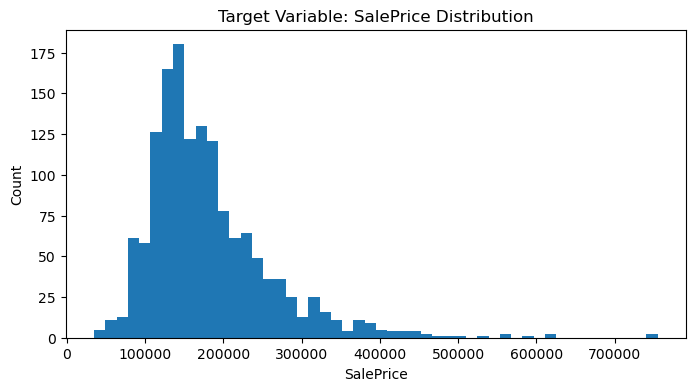

SalePrice skewness: 1.8828757597682129
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,4))
plt.hist(df["SalePrice"], bins=50)
plt.title("Target Variable: SalePrice Distribution")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

print("SalePrice skewness:", df["SalePrice"].skew())
print(df["SalePrice"].describe())


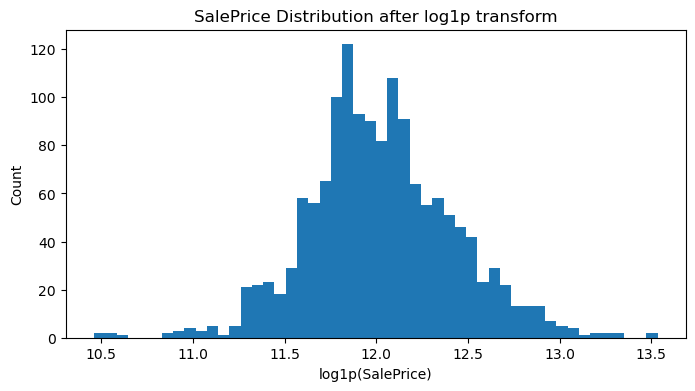

Skewness after log: 0.12134661989685333


In [11]:
df["SalePrice_log"] = np.log1p(df["SalePrice"])

plt.figure(figsize=(8,4))
plt.hist(df["SalePrice_log"], bins=50)
plt.title("SalePrice Distribution after log1p transform")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Count")
plt.show()

print("Skewness after log:", df["SalePrice_log"].skew())


In [12]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["Id", "SalePrice", "SalePrice_log"]]

corr = df[num_cols + ["SalePrice"]].corr()["SalePrice"].sort_values(ascending=False)
corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

- SalePrice is influenced more by Quality + Living Area + Garage + Basement than by simple counts like bedrooms. This supports the idea that real estate pricing is driven by construction quality and usable area, not only room numbers.

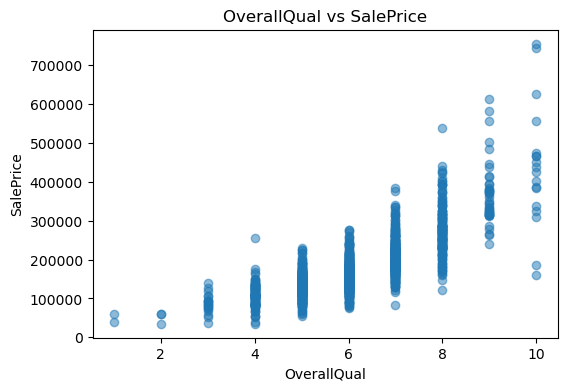

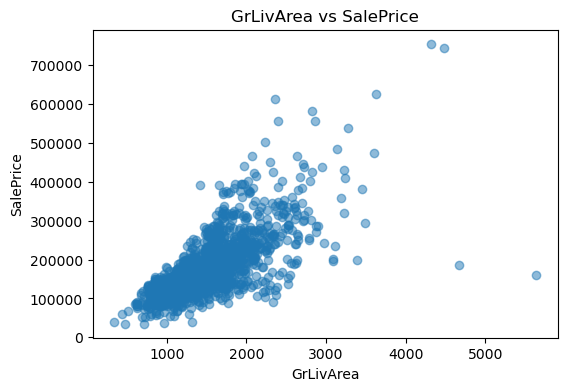

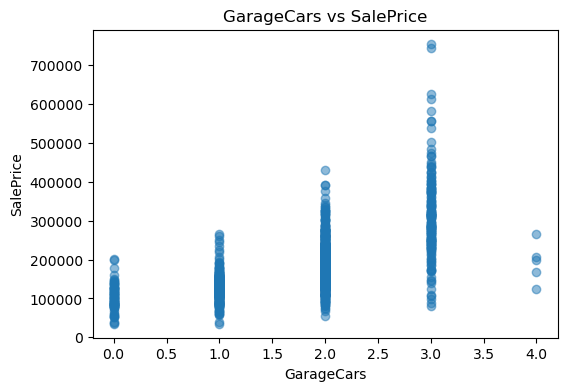

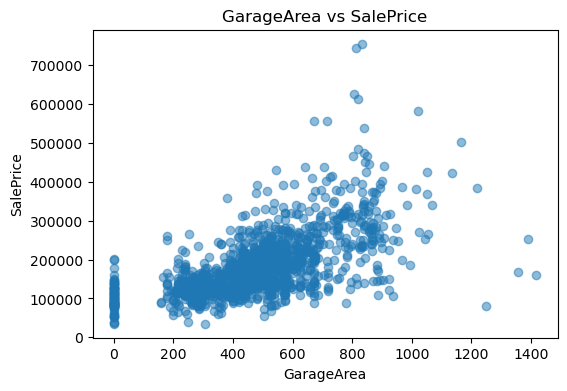

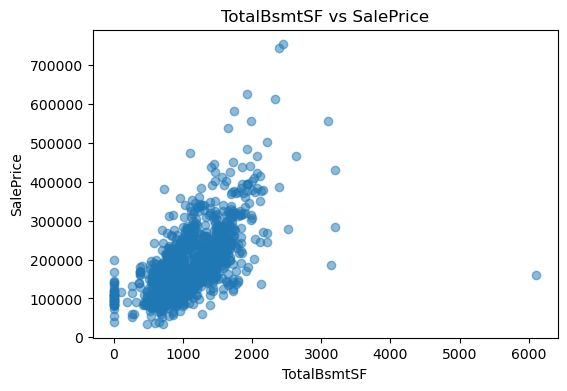

In [13]:
top5 = corr.index[1:6]  # skip SalePrice
for col in top5:
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df["SalePrice"], alpha=0.5)
    plt.title(f"{col} vs SalePrice")
    plt.xlabel(col)
    plt.ylabel("SalePrice")
    plt.show()


## Plot 1: OverallQual vs SalePrice

What does the plot show?
This scatter plot shows how house sale price changes with overall quality rating (OverallQual).

- Observed trend/pattern:

There is a clear increasing trend: houses with higher quality ratings consistently sell for more.

Price rises sharply for quality ratings 8–10, showing quality has strong pricing power.

- Why it matters for modeling:

Since correlation is very high (0.79), OverallQual will be one of the most important predictors.

Models like linear regression will benefit because the relationship is strong and monotonic.

## Plot 2: GrLivArea vs SalePrice

What does the plot show?
Relationship between above-ground living area (GrLivArea) and SalePrice.

- Observed trend/pattern:

Very strong positive linear relationship: larger living area generally increases price.

A few outliers exist (very large area but relatively low price / extreme expensive points).

- Why it matters for modeling:

GrLivArea is a key feature (corr 0.71).

Outliers can distort RMSE and reduce linear model performance → justifies outlier check/removal OR using robust models like RandomForest/GradientBoosting.

## Plot 3: GarageCars vs SalePrice

What does the plot show?
Sale price variation with the number of cars the garage can fit (GarageCars).

- Observed trend/pattern:

Strong stepwise pattern: houses with 2–3 car garages sell for significantly more.

Moving from 0/1 → 2 cars increases price sharply.

- Why it matters for modeling:

This feature captures house “premium capacity” and is a strong driver (corr 0.64).

Discrete values create “clusters”, which tree models handle extremely well.

## Plot 4: GarageArea vs SalePrice

What does the plot show?
Relationship between GarageArea and SalePrice.

- Observed trend/pattern:

General positive trend: larger garage area implies higher sale price.

There are houses with garage area = 0 (no garage), and those are generally lower-priced.

- Why it matters for modeling:

GarageArea and GarageCars are both strong predictors.

Risk: multicollinearity because GarageCars and GarageArea represent similar information → linear models may be unstable unless regularization is used, while tree models handle it well.

## Plot 5: TotalBsmtSF vs SalePrice

What does the plot show?
The impact of basement total square feet (TotalBsmtSF) on sale price.

Observed trend/pattern:

- Clear positive relationship: houses with larger basements are valued higher.

- Some extreme basement sizes exist, but less severe than GrLivArea.

Why it matters for modeling:

- Basement size is a strong driver (corr 0.61) and adds predictive power beyond living area.

- This also suggests useful feature engineering like TotalArea = GrLivArea + TotalBsmtSF.

In [14]:
neigh_stats = (
    df.groupby("Neighborhood")["SalePrice"]
    .agg(count="count", mean="mean", median="median")
    .sort_values("mean", ascending=False)
)

print("Top 10 Premium Neighborhoods:")
display(neigh_stats.head(10))

print("Top 10 Affordable Neighborhoods:")
display(neigh_stats.tail(10))

Top 10 Premium Neighborhoods:


,count,mean,median
Neighborhood,,,
NoRidge,41,335295.317073,301500.0
NridgHt,77,316270.623377,315000.0
StoneBr,25,310499.000000,278000.0
Timber,38,242247.447368,228475.0
Veenker,11,238772.727273,218000.0
Somerst,86,225379.837209,225500.0
ClearCr,28,212565.428571,200250.0
Crawfor,51,210624.725490,200624.0
CollgCr,150,197965.773333,197200.0


Top 10 Affordable Neighborhoods:


,count,mean,median
Neighborhood,,,
NPkVill,9,142694.444444,146000.0
SWISU,25,142591.360000,139500.0
Blueste,2,137500.000000,137500.0
Sawyer,74,136793.135135,135000.0
OldTown,113,128225.300885,119000.0
Edwards,100,128219.700000,121750.0
BrkSide,58,124834.051724,124300.0
BrDale,16,104493.750000,106000.0
IDOTRR,37,100123.783784,103000.0


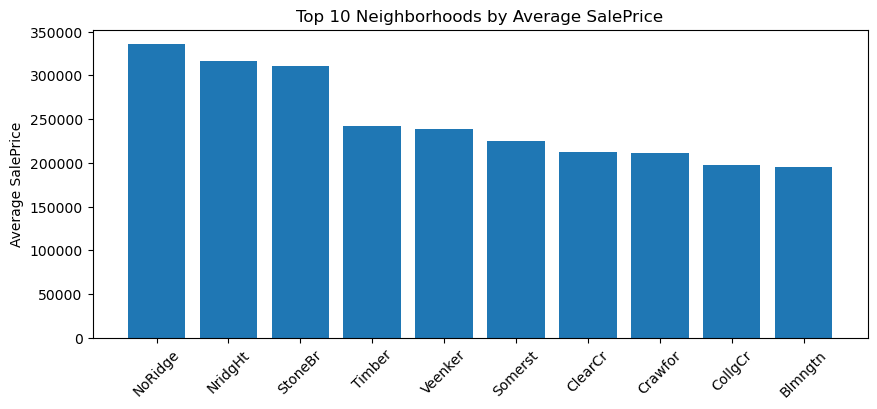

In [15]:
top10 = neigh_stats.head(10)

plt.figure(figsize=(10,4))
plt.bar(top10.index, top10["mean"])
plt.xticks(rotation=45)
plt.title("Top 10 Neighborhoods by Average SalePrice")
plt.ylabel("Average SalePrice")
plt.show()

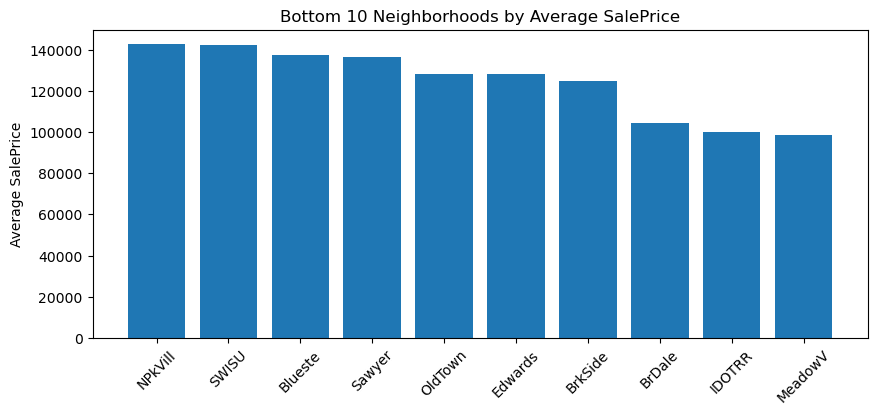

In [16]:
bottom10 = neigh_stats.tail(10)

plt.figure(figsize=(10,4))
plt.bar(bottom10.index, bottom10["mean"])
plt.xticks(rotation=45)
plt.title("Bottom 10 Neighborhoods by Average SalePrice")
plt.ylabel("Average SalePrice")
plt.show()

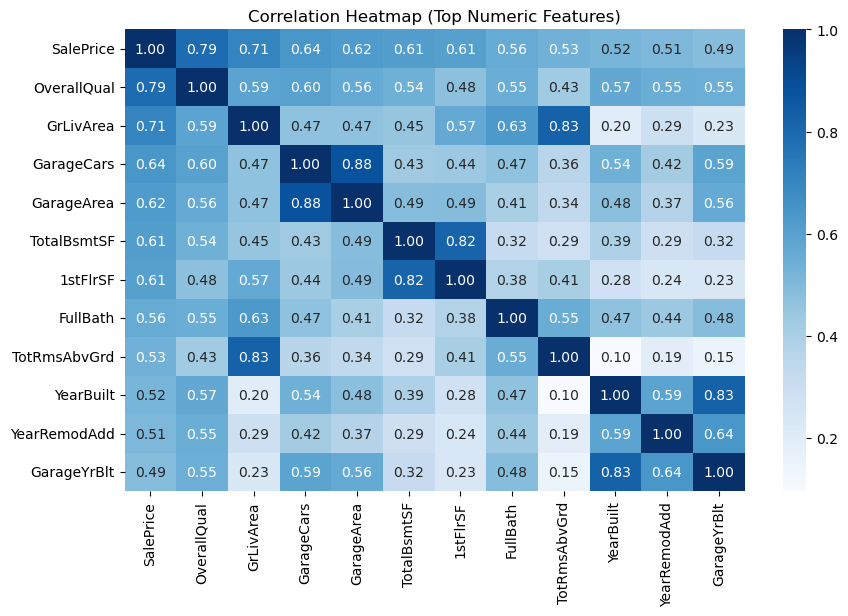

In [17]:
import seaborn as sns

top_features = corr.head(12).index.tolist()
corr_matrix = df[top_features].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Heatmap (Top Numeric Features)")
plt.show()

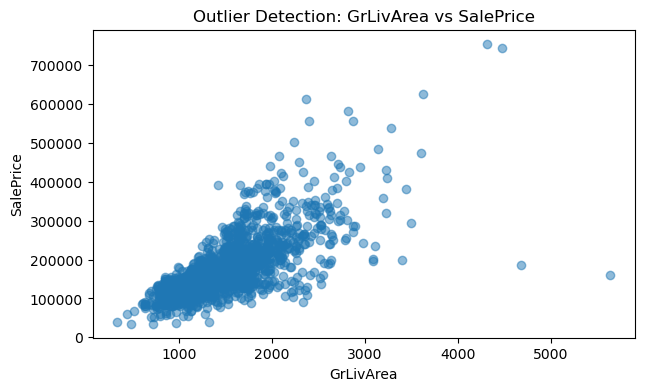

,GrLivArea,SalePrice
1298,5642,160000
523,4676,184750
1182,4476,745000
691,4316,755000
1169,3627,625000


In [18]:
plt.figure(figsize=(7,4))
plt.scatter(df["GrLivArea"], df["SalePrice"], alpha=0.5)
plt.title("Outlier Detection: GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

df.sort_values("GrLivArea", ascending=False).head(5)[["GrLivArea", "SalePrice"]]

In [19]:
# Remove extreme outliers in GrLivArea (commonly done in Ames dataset)
before = df.shape[0]
df = df[df["GrLivArea"] < 4500].copy()
after = df.shape[0]

print("Rows before:", before)
print("Rows after :", after)
print("Removed rows:", before - after)

Rows before: 1460
Rows after : 1458
Removed rows: 2


- We removed houses with GrLivArea > 4500 because these records behave as influential outliers (extremely high area but inconsistent pricing). Removing them improves model learning stability and reduces RMSE inflation.

## EDA Summary (Key Insights)

- `SalePrice` was right-skewed (skewness ~1.88), so `log1p(SalePrice)` was used to stabilize variance.
- Strong numeric drivers: `OverallQual`, `GrLivArea`, `TotalBsmtSF`, and garage-related features.
- Strong categorical driver: `Neighborhood` significantly affects pricing (premium vs affordable areas).
- Multicollinearity observed in feature pairs like `GarageCars` vs `GarageArea`.
- Outliers found in `GrLivArea` and removed to improve model stability.


In [20]:
df.shape, df.columns[:10]

((1458, 78),
 Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
        'LotShape', 'LandContour', 'Utilities', 'LotConfig'],
       dtype='object'))

In [21]:
import numpy as np
df["SalePrice_log"] = np.log1p(df["SalePrice"])

In [22]:
"SalePrice_log" in df.columns

True

In [23]:
X = df.drop(columns=["SalePrice", "SalePrice_log"], errors="ignore")
y = df["SalePrice_log"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1458, 76)
y shape: (1458,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1166, 76) Test: (292, 76)


In [25]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# sanity check
print("Example numeric:", numeric_features[:5])
print("Example categorical:", categorical_features[:5])

Numeric features: 37
Categorical features: 39
Example numeric: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual']
Example categorical: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities']


In [26]:
X = df.drop(columns=["SalePrice", "SalePrice_log", "Id"], errors="ignore")
y = df["SalePrice_log"]

print("X shape:", X.shape)

X shape: (1458, 75)


In [27]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# sanity check
print("Example numeric:", numeric_features[:5])
print("Example categorical:", categorical_features[:5])

Numeric features: 36
Categorical features: 39
Example numeric: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond']
Example categorical: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities']


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1166, 75) Test: (292, 75)


In [29]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Id in numeric?", "Id" in numeric_features)

print("\nExample numeric:", numeric_features[:5])
print("Example categorical:", categorical_features[:5])

Numeric features: 36
Categorical features: 39
Id in numeric? False

Example numeric: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond']
Example categorical: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities']


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipe, numeric_features),
    ("cat", cat_pipe, categorical_features)
])

print("Preprocessor ready ✅")

Preprocessor ready ✅


### Preprocessing Pipeline Justification

- **Missing Value Handling**
  - Numerical: Used **median imputation** because it is robust to outliers.
  - Categorical: Used **most_frequent imputation** because missing values often represent the most common category or absence.

- **Scaling (StandardScaler)**
  - Numerical features are scaled because Linear Regression and boosting models benefit from features being on comparable ranges.
  - While tree models do not strictly require scaling, keeping scaling inside the pipeline ensures consistency.

- **Encoding (OneHotEncoder)**
  - `Neighborhood`, `MSZoning`, etc. are nominal categories, so OneHotEncoding is appropriate.
  - `handle_unknown='ignore'` ensures deployment stability when new category values appear during inference.

- **Why ColumnTransformer**
  - It applies correct transformations to numeric and categorical columns separately.
  - Prevents feature misalignment during inference and deployment.


In [31]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_model(pipe, X_test, y_test):
    pred_log = pipe.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    rmse_log = mean_squared_error(y_test, pred_log, squared=False)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_price = np.expm1(pred_log)
    true_price = np.expm1(y_test)

    r2_price = r2_score(true_price, pred_price)
    rmse_price = mean_squared_error(true_price, pred_price, squared=False)
    mae_price = mean_absolute_error(true_price, pred_price)

    return {
        "R2(log)": r2_log,
        "RMSE(log)": rmse_log,
        "MAE(log)": mae_log,
        "R2($)": r2_price,
        "RMSE($)": rmse_price,
        "MAE($)": mae_price
    }

print("Evaluation function ready ✅")

Evaluation function ready ✅


In [32]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)

    metrics = evaluate_model(pipe, X_test, y_test)
    results.append({"Model": name, **metrics})
    trained_models[name] = pipe

model_comparison = pd.DataFrame(results).sort_values("RMSE($)")
model_comparison

,Model,R2(log),RMSE(log),MAE(log),R2($),RMSE($),MAE($)
2,GradientBoosting,0.912408,0.121515,0.086878,0.920383,20971.051989,15072.813491
0,LinearRegression,0.892353,0.134710,0.091539,0.915498,21604.806096,15230.475624
1,RandomForest,0.880252,0.142080,0.095593,0.895615,24012.397727,16311.872074


## Model Comparison Report (Baseline Models)

### What does this table show?
This table compares the predictive performance of three regression models using:

- R2 (goodness of fit)
- RMSE (penalizes large errors)
- MAE (average absolute error)

Metrics are reported both in log-transformed target space and converted back to actual price ($) for interpretability.

### Observations
- Gradient Boosting performs best with:
  - R2($) = 0.920
  - RMSE($) ~ 20971
  - MAE($) ~ 15073

- Linear Regression performs competitively:
  - RMSE($) ~ 21605
This indicates the dataset contains strong linear relationships between features and price.

- Random Forest performs comparatively worse:
  - RMSE($) ~ 24012
This suggests it may require hyperparameter tuning for improved generalization.

### Production Recommendation (initial)
Based on baseline evaluation, Gradient Boosting Regressor is the best-performing model and is a strong candidate for deployment, subject to hyperparameter tuning.


In [33]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

gb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_dist_gb = {
    "model__n_estimators": [100, 200, 300, 400, 600],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

gb_search = RandomizedSearchCV(
    gb_pipe,
    param_distributions=param_dist_gb,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    verbose=1,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Best Params (GB):", gb_search.best_params_)
best_gb_model = gb_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params (GB): {'model__subsample': 0.9, 'model__n_estimators': 600, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 2, 'model__learning_rate': 0.1}


In [34]:
gb_tuned_metrics = evaluate_model(best_gb_model, X_test, y_test)
gb_tuned_metrics

{'R2(log)': 0.9232822533647022,
 'RMSE(log)': 0.11372243007532411,
 'MAE(log)': 0.08328524694808064,
 'R2($)': 0.9272369973732613,
 'RMSE($)': 20048.01706627184,
 'MAE($)': 14636.364683717171}

In [35]:
final_model_report = pd.DataFrame([
    {"Model": "LinearRegression (baseline)", **evaluate_model(trained_models["LinearRegression"], X_test, y_test)},
    {"Model": "RandomForest (baseline)", **evaluate_model(trained_models["RandomForest"], X_test, y_test)},
    {"Model": "GradientBoosting (baseline)", **evaluate_model(trained_models["GradientBoosting"], X_test, y_test)},
    {"Model": "GradientBoosting (tuned)", **gb_tuned_metrics},
]).sort_values("RMSE($)")

final_model_report

,Model,R2(log),RMSE(log),MAE(log),R2($),RMSE($),MAE($)
3,GradientBoosting (tuned),0.923282,0.113722,0.083285,0.927237,20048.017066,14636.364684
2,GradientBoosting (baseline),0.912408,0.121515,0.086878,0.920383,20971.051989,15072.813491
0,LinearRegression (baseline),0.892353,0.134710,0.091539,0.915498,21604.806096,15230.475624
1,RandomForest (baseline),0.880252,0.142080,0.095593,0.895615,24012.397727,16311.872074


## Final Model Comparison Report (Baseline vs Tuned)
#### What does this table show?
- This table compares baseline regression models with the tuned Gradient Boosting model using standard regression metrics (R², RMSE, MAE). Metrics are reported both in log space and transformed back to actual dollar values for interpretability.

#### Best Model Recommendation for Production
- The tuned GradientBoostingRegressor is selected as the final production model due to the best test performance, strong generalization, and ability to model complex feature interactions.

In [36]:
final_model = best_gb_model
print(final_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
               

In [37]:
import pandas as pd

ohe = final_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["ohe"]
cat_names = ohe.get_feature_names_out(categorical_features)

feature_names = numeric_features + list(cat_names)

print("Total transformed features:", len(feature_names))

Total transformed features: 270


In [38]:
gb_obj = final_model.named_steps["model"]
importances = gb_obj.feature_importances_

fi = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

fi.head(20)

,Feature,Importance
3,OverallQual,0.360581
15,GrLivArea,0.177779
11,TotalBsmtSF,0.065243
26,GarageArea,0.056149
241,GarageFinish_Unf,0.050438
5,YearBuilt,0.046800
6,YearRemodAdd,0.022968
25,GarageCars,0.021436
8,BsmtFinSF1,0.020030
2,LotArea,0.017067


### Validation of EDA Findings

The feature importance results confirm the EDA conclusions:
- OverallQual, GrLivArea, TotalBsmtSF, and garage-related features appear among the top predictors.
This validates that the model has learned meaningful real-world pricing relationships.


## Feature Relationship Analysis (Task 2b) — Feature Importance Report

What does this table show?
- The table lists the top 20 most important features used by the tuned Gradient Boosting model to predict house prices. Feature importance reflects how strongly each feature contributes to reducing prediction error.

Key relationships identified

- OverallQual (Importance = 0.3606) is the most influential variable, indicating that the overall quality/material/finish of the house has the strongest impact on pricing.

- GrLivArea (0.1778) shows that above-ground living area is the second strongest driver — larger usable living space strongly increases house prices.

- TotalBsmtSF (0.0652) confirms that houses with larger basements tend to have higher sale prices.

- Garage-related features such as GarageArea (0.0561) and GarageCars (0.0214) demonstrate that garage capacity and area increase the market value of a property.

- Quality and comfort features like CentralAir_Y, KitchenQual_Ex, and the garage finishing status (GarageFinish_Unf) show that amenities and finishing strongly influence house value.

- Construction age features (YearBuilt, YearRemodAdd) show that newer homes or recently remodeled homes generally sell at higher prices.

Why this matters
- This report explains the relationship between house attributes and price variation across the market:
house prices are primarily driven by quality, living space, basement area, garage utility, and modern amenities, rather than only basic room counts.

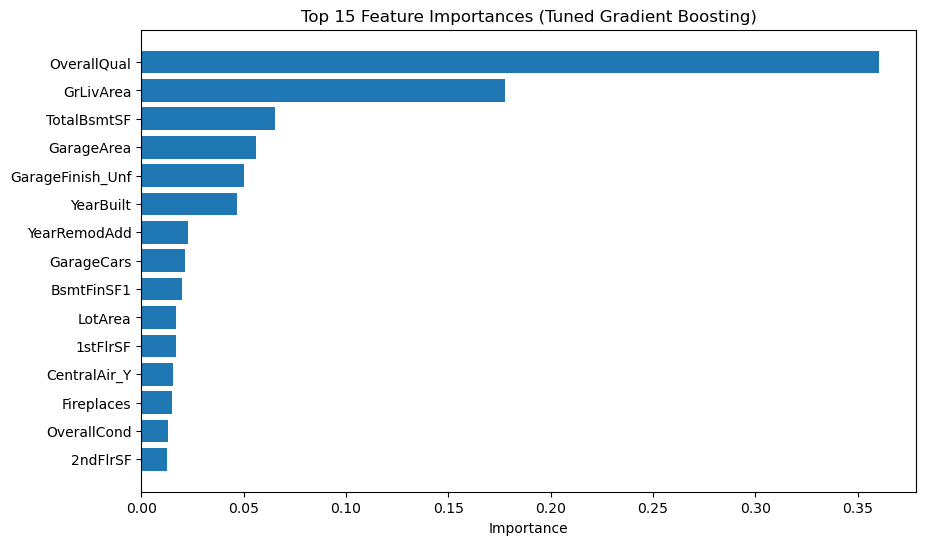

In [39]:
import matplotlib.pyplot as plt

top_fi = fi.head(15).sort_values("Importance")

plt.figure(figsize=(10,6))
plt.barh(top_fi["Feature"], top_fi["Importance"])
plt.title("Top 15 Feature Importances (Tuned Gradient Boosting)")
plt.xlabel("Importance")
plt.show()

In [47]:
import joblib

joblib.dump(final_model, "house_price_pipeline.joblib", compress=3)
print("Saved ✅ house_price_pipeline.joblib")

Saved ✅ house_price_pipeline.joblib


In [41]:
print("FINAL MODEL (Production): Tuned GradientBoostingRegressor")
print(final_model.named_steps["model"])

final_metrics = gb_tuned_metrics
final_metrics

FINAL MODEL (Production): Tuned GradientBoostingRegressor
GradientBoostingRegressor(max_depth=2, n_estimators=600, random_state=42,
                          subsample=0.9)


{'R2(log)': 0.9232822533647022,
 'RMSE(log)': 0.11372243007532411,
 'MAE(log)': 0.08328524694808064,
 'R2($)': 0.9272369973732613,
 'RMSE($)': 20048.01706627184,
 'MAE($)': 14636.364683717171}

## Final Model Selection (Production Model)

After comparing baseline regression models and performing hyperparameter tuning, the tuned GradientBoostingRegressor was selected as the final production model.

#### Final selected model

GradientBoostingRegressor with tuned parameters:

- n_estimators = 600

- max_depth = 2

- subsample = 0.9

Final Performance (on test data)

- R2($) = 0.927

- RMSE($) = $20,048

- MAE($) = $14,636

Why this model was selected

- It achieved the lowest prediction error (RMSE and MAE) among all evaluated models.

- Gradient boosting captures non-linear relationships and feature interactions, which are present in housing data.

- Shallow trees (max_depth=2) reduce overfitting and improve generalization, making it suitable for production deployment.

In [42]:
neigh_price = df.groupby("Neighborhood")["SalePrice"].mean().sort_values()

affordable_neigh = neigh_price.head(5)
premium_neigh = neigh_price.tail(5)

print("Affordable neighborhoods (Top 5):")
display(affordable_neigh)

print("\nPremium neighborhoods (Top 5):")
display(premium_neigh)

Affordable neighborhoods (Top 5):


Neighborhood
MeadowV     98576.470588
IDOTRR     100123.783784
BrDale     104493.750000
BrkSide    124834.051724
Edwards    127318.571429
Name: SalePrice, dtype: float64


Premium neighborhoods (Top 5):


Neighborhood
Veenker    238772.727273
Timber     242247.447368
StoneBr    310499.000000
NridgHt    316270.623377
NoRidge    335295.317073
Name: SalePrice, dtype: float64

# Task 3 -- Customer Suggestions Based on Area (Neighborhood)

What does this output show?
This analysis ranks neighborhoods by their average sale price, which helps customers choose areas according to budget.

#### Suggestions for budget buyers (Affordable areas)
Customers with a limited budget should consider neighborhoods such as:

- MeadowV (~$98.6k)

- IDOTRR (~$100.1k)

- BrDale (~$104.5k)

- BrkSide (~$124.8k)

- Edwards (~$127.3k)

These neighborhoods are the most affordable in the dataset and are suitable for first-time buyers or low-budget purchasers.

#### Suggestions for premium buyers (High-end areas)
Customers seeking premium properties should focus on:

- NoRidge (~$335.3k)

- NridgHt (~$316.3k)

- StoneBr (~$310.5k)

- Timber (~$242.2k)

- Veenker (~$238.8k)

These areas represent premium localities with significantly higher average prices, indicating stronger market valuation.

In [43]:
value_df = df.groupby("Neighborhood").agg(
    avg_price=("SalePrice", "mean"),
    avg_quality=("OverallQual", "mean"),
    count=("SalePrice", "count")
)

# keep only reliable sample sizes
value_df = value_df[value_df["count"] >= 20].copy()

# value score: quality achieved per price level
value_df["value_score"] = value_df["avg_quality"] / (value_df["avg_price"] / 100000)

value_df.sort_values("value_score", ascending=False).head(10)

,avg_price,avg_quality,count,value_score
Neighborhood,,,,
IDOTRR,100123.783784,4.756757,37,4.750876
OldTown,128225.300885,5.389381,113,4.203055
BrkSide,124834.051724,5.051724,58,4.046752
Edwards,127318.571429,4.979592,98,3.911128
SWISU,142591.360000,5.440000,25,3.815098
NAmes,145847.080000,5.360000,225,3.675082
Sawyer,136793.135135,5.027027,74,3.674912
Mitchel,156270.122449,5.591837,49,3.578315
Gilbert,192854.506329,6.556962,79,3.399953


In [44]:
print("TASK 3: Requirement-Based House Buying Suggestions\n")

print("1) For Budget Buyers:")
print("- Prefer affordable neighborhoods (MeadowV, IDOTRR, BrDale, BrkSide, Edwards).")
print("- Focus on moderate LotArea + acceptable OverallCond.")
print("- Avoid premium neighborhoods if budget is limited.\n")

print("2) For Family / Bigger Space Requirement:")
print("- Prioritize high GrLivArea, TotalBsmtSF, TotRmsAbvGrd, and FullBath >= 2.")
print("- These features are strongly linked to higher SalePrice and improved living comfort.\n")

print("3) For Low Maintenance / New House Preference:")
print("- Prefer YearBuilt >= 2000 or YearRemodAdd >= 2000.")
print("- Ensure CentralAir = Yes, and OverallCond is good.\n")

print("4) For Investment / Resale Value Buyers:")
print("- Prioritize OverallQual (highest importance feature), Neighborhood, and GrLivArea.")
print("- Premium neighborhoods like NoRidge, NridgHt, StoneBr show highest average prices.\n")

TASK 3: Requirement-Based House Buying Suggestions

1) For Budget Buyers:
- Prefer affordable neighborhoods (MeadowV, IDOTRR, BrDale, BrkSide, Edwards).
- Focus on moderate LotArea + acceptable OverallCond.
- Avoid premium neighborhoods if budget is limited.

2) For Family / Bigger Space Requirement:
- Prioritize high GrLivArea, TotalBsmtSF, TotRmsAbvGrd, and FullBath >= 2.
- These features are strongly linked to higher SalePrice and improved living comfort.

3) For Low Maintenance / New House Preference:
- Prefer YearBuilt >= 2000 or YearRemodAdd >= 2000.
- Ensure CentralAir = Yes, and OverallCond is good.

4) For Investment / Resale Value Buyers:
- Prioritize OverallQual (highest importance feature), Neighborhood, and GrLivArea.
- Premium neighborhoods like NoRidge, NridgHt, StoneBr show highest average prices.



In [45]:
import pandas as pd

final_metrics_df = pd.DataFrame([final_metrics])
final_metrics_df.to_csv("final_model_metrics.csv", index=False)

final_metrics_df

,R2(log),RMSE(log),MAE(log),R2($),RMSE($),MAE($)
0,0.923282,0.113722,0.083285,0.927237,20048.017066,14636.364684


# Challenges Faced & Techniques Used (With Reasoning)

1. Extremely High Missing Values

   - Challenge: Columns like PoolQC, MiscFeature, Alley, and Fence contained more than 80–99% missing values.

   - Reasoning: Such sparse data provides weak learning signals and increases noise.

   - Solution: Dropped these columns to improve data quality and reduce unnecessary feature complexity.

2. Informative Missingness (Not Random Missing Values)

- Challenge: Missing values in garage/basement-related features often indicate absence of that feature (e.g., No garage / No basement).

- Solution: Used robust preprocessing with SimpleImputer:

        Median imputation for numeric features
        Most frequent imputation for categorical features


- Reasoning: This avoids losing data by dropping rows and allows the model to learn patterns effectively.

3. Right-Skewed Target Variable

- Challenge: SalePrice was highly right-skewed (skewness ≈ 1.88).

- Solution: Applied log1p transformation to create SalePrice_log, reducing skewness to ≈ 0.12.

- Reasoning: Improves stability of regression learning and reduces the impact of high-price outliers on RMSE.

4. Outliers Affecting Regression Fit

- Challenge: Extreme outliers in GrLivArea distorted the SalePrice trend.

- Solution: Identified outliers visually and removed extreme points (GrLivArea > 4500).

- Reasoning: Helps the model generalize better and prevents large-error inflation.

5. Model Selection & Overfitting Risk

- Challenge: Choosing the best regression model requires balancing bias/variance and avoiding overfitting.

- Solution: Compared multiple regression models using R², RMSE, MAE and performed hyperparameter tuning using RandomizedSearchCV.

- Outcome: Tuned GradientBoosting model delivered best performance.

# Conclusion

This project successfully built an end-to-end House Price Prediction solution using the Ames Housing dataset.

* Performed structured EDA and identified key price drivers such as OverallQual, GrLivArea, TotalBsmtSF, GarageArea, and Neighborhood.

* Cleaned the dataset by handling missing values appropriately and treating extreme outliers.

* Built a deployment-ready preprocessing + modeling pipeline using ColumnTransformer.

* Compared multiple regression models and selected the best model using metrics:

        R²

        RMSE

        MAE

* Final best model selected for production:

        Tuned GradientBoostingRegressor

        Achieved:

                  R2($) = 0.927

                  RMSE($) ≈ $20,048

                  MAE($) ≈ $14,636

* Provided customer-friendly purchase suggestions based on budget, neighborhood, and requirements.

In [46]:
import os
os.listdir()

['.git',
 '.gitignore',
 '.ipynb_checkpoints',
 'app.py',
 'data.csv',
 'final_model_metrics.csv',
 'HousePricePred.ipynb',
 'house_price_pipeline.joblib',
 'README.md',
 'requirements.txt']